# Gaussian Mixture Models (GMM)

## Core Idea

K-Means assigns each point to exactly one cluster — a hard, all-or-nothing decision. GMM takes a fundamentally different approach: it assumes the data was **generated by a mixture of several Gaussian distributions**, and instead of asking *which cluster does this point belong to*, it asks *what is the probability that this point came from each cluster*. This is called **soft clustering**.

A single Gaussian models data with one peak. But real data often has multiple peaks — consider measuring the heights of students in a mixed classroom of boys and girls. The histogram shows two humps, each roughly bell-shaped. A GMM models each hump with its own Gaussian and learns how much each one contributes to the overall data.

## The Mathematical Model

The probability density of a point $\mathbf{x}$ under a GMM with $K$ components is:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \mu_k, \Sigma_k)$$

Where:

- $\pi_k$ is the **mixing weight** of component $k$ — the prior probability of a point being generated by Gaussian $k$. These must satisfy $\sum_{k=1}^{K} \pi_k = 1$
- $\mu_k$ is the **mean** (center) of component $k$
- $\Sigma_k$ is the **covariance matrix** of component $k$, which controls the shape, spread, and orientation of the cluster
- $\mathcal{N}(\mathbf{x} \mid \mu_k, \Sigma_k)$ is the multivariate Gaussian density:

$$\mathcal{N}(\mathbf{x} \mid \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{d/2}|\Sigma_k|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \mu_k)^T \Sigma_k^{-1} (\mathbf{x} - \mu_k)\right)$$

The covariance matrix $\Sigma_k$ is what makes GMM fundamentally more powerful than K-Means. K-Means implicitly assumes all clusters are spherical and equally sized. GMM clusters can be **elliptical, rotated, and differently sized** depending on $\Sigma_k$.

## The Generative Process and Latent Variables

GMM is a **generative model** — it describes a probabilistic story for how the data was created:

1. For each data point $\mathbf{x}_i$, first pick a component: $z_i \sim \text{Categorical}(\pi_1, \pi_2, \ldots, \pi_K)$
2. Then sample the point from that component's Gaussian: $\mathbf{x}_i \sim \mathcal{N}(\mu_{z_i}, \Sigma_{z_i})$

The variable $z_i$ — which Gaussian generated point $i$ — is **never observed**. It is called a **latent variable**. We can only observe $\mathbf{x}_i$. The goal of learning is to infer both the parameters $\theta = \{\pi_k, \mu_k, \Sigma_k\}$ and the latent structure $z_i$ from the data alone.

## Why Maximum Likelihood Is Hard

We want to maximize the log-likelihood of the observed data:

$$\log p(\mathbf{X} \mid \theta) = \sum_{i=1}^{n} \log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}_i \mid \mu_k, \Sigma_k)$$

The problem is the **sum inside the log**. This prevents a clean closed-form solution — taking the derivative and setting it to zero yields equations that depend on the unknown responsibilities $\gamma(z_{ik})$, which themselves depend on the unknown parameters. The problem is circular.

The solution is the **Expectation-Maximization (EM) algorithm**.

## Expectation-Maximization (EM)

EM breaks the circular dependency by alternating between two steps, each of which is tractable given the output of the other.

### Initialization

Before EM begins, we need starting values for $\mu_k$, $\Sigma_k$, and $\pi_k$. A common approach is to run K-Means first and use its cluster centers as initial means. Random initialization also works but may converge more slowly.

### E-Step (Expectation): Compute Responsibilities

Given the current parameters $\theta$, compute the **responsibility** $\gamma(z_{ik})$ — the posterior probability that point $\mathbf{x}_i$ was generated by component $k$:

$$\gamma(z_{ik}) = \frac{\pi_k \, \mathcal{N}(\mathbf{x}_i \mid \mu_k, \Sigma_k)}{\displaystyle\sum_{j=1}^{K} \pi_j \, \mathcal{N}(\mathbf{x}_i \mid \mu_j, \Sigma_j)}$$

This is simply Bayes' theorem — the numerator is the joint probability of the point and the component, and the denominator normalizes across all components. The result for each point is a **probability distribution over clusters**, not a hard assignment. For example:

| Point | Cluster 1 | Cluster 2 |
|---|---|---|
| $\mathbf{x}_1$ | 0.85 | 0.15 |
| $\mathbf{x}_2$ | 0.40 | 0.60 |

### M-Step (Maximization): Update Parameters

Given the responsibilities computed in the E-step, update the parameters to maximize the expected log-likelihood.

**Update means** — weighted average of all points, where weights are the responsibilities:

$$\mu_k^{\text{new}} = \frac{\displaystyle\sum_{i=1}^{n} \gamma(z_{ik})\, \mathbf{x}_i}{\displaystyle\sum_{i=1}^{n} \gamma(z_{ik})}$$

**Update covariances** — weighted sample covariance around the new mean:

$$\Sigma_k^{\text{new}} = \frac{\displaystyle\sum_{i=1}^{n} \gamma(z_{ik})\, (\mathbf{x}_i - \mu_k^{\text{new}})(\mathbf{x}_i - \mu_k^{\text{new}})^T}{\displaystyle\sum_{i=1}^{n} \gamma(z_{ik})}$$

**Update mixing weights** — the effective fraction of points assigned to each component:

$$\pi_k^{\text{new}} = \frac{1}{n} \sum_{i=1}^{n} \gamma(z_{ik})$$

### Convergence

After each M-step, compute the log-likelihood $\log p(\mathbf{X} \mid \theta)$. EM **guarantees** the log-likelihood is non-decreasing at every iteration. Repeat E and M steps until the improvement in log-likelihood falls below a small threshold.

## GMM vs K-Means

| Property | K-Means | GMM |
|---|---|---|
| Cluster assignment | Hard (one cluster per point) | Soft (probability over all clusters) |
| Cluster shape | Spherical only | Elliptical, rotated, any orientation |
| Covariance | Implicitly equal and spherical | Full, per-cluster covariance matrix |
| Probabilistic output | No | Yes — $p(\text{cluster} \mid \mathbf{x})$ |
| Optimization | EM-like (Lloyd's algorithm) | EM algorithm |
| Objective | Minimize WCSS | Maximize log-likelihood |

## Choosing the Number of Components $K$

Like K-Means, GMM requires specifying $K$. The standard approach is to fit GMMs with different values of $K$ and compare them using an **information criterion** — a measure that balances fit quality against model complexity.

**BIC (Bayesian Information Criterion):**

$$BIC = -2\log\hat{L} + p\log n$$

Where $\hat{L}$ is the maximized likelihood, $p$ is the number of free parameters, and $n$ is the number of data points. The penalty $p \log n$ discourages overly complex models. **Choose the $K$ that minimizes BIC.**

**AIC (Akaike Information Criterion):**

$$AIC = -2\log\hat{L} + 2p$$

AIC has a lighter penalty than BIC and tends to select slightly larger models. BIC is generally preferred for clustering because it is more conservative.

## Applications of GMM

Because GMM explicitly models $p(\mathbf{x})$, it can do more than just cluster:

**Density Estimation:** The fitted mixture $p(\mathbf{x}) = \sum_k \pi_k \mathcal{N}(\mathbf{x} \mid \mu_k, \Sigma_k)$ is a full probability density. You can evaluate the likelihood of any new point.

**Anomaly Detection:** A point with very low density $p(\mathbf{x}) < \tau$ (for some threshold $\tau$) is likely an outlier. This is used in fraud detection, network intrusion detection, and manufacturing quality control.

**Generative Modeling:** Because GMM describes a generative process, you can sample new synthetic data points from the fitted model.

## When GMM Fails

GMM inherits the Gaussian assumption — if the true clusters are not roughly elliptical, EM will converge to a poor solution. For highly non-convex shapes (like the two moons dataset), DBSCAN or spectral clustering are more appropriate. GMM also requires careful initialization and can converge to different local optima depending on the starting point, which is why multiple random restarts are recommended.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

np.random.seed(42)

X, y_true = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=1.5,
    random_state=42
)

# Apply linear transformation to make clusters elliptical
transformation = np.array([[0.6, -0.6],
                           [-0.4, 0.8]])

X = np.dot(X, transformation)

In [2]:
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_train)

kmeans_labels = kmeans.predict(X_test)

kmeans_silhouette = silhouette_score(X_test, kmeans_labels)

print("KMeans Silhouette Score:", kmeans_silhouette)

KMeans Silhouette Score: 0.544015938801701


In [3]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_train)

gmm_labels = gmm.predict(X_test)

gmm_silhouette = silhouette_score(X_test, gmm_labels)

print("GMM Silhouette Score:", gmm_silhouette)

GMM Silhouette Score: 0.5640573352600687


In [4]:
probs = gmm.predict_proba(X_test)

print("First 5 probability assignments:")
print(probs[:5])

First 5 probability assignments:
[[7.35729299e-26 5.95983861e-33 1.00000000e+00]
 [1.00000000e+00 1.81850119e-10 2.26417286e-29]
 [1.42346209e-16 8.29683787e-27 1.00000000e+00]
 [3.54276025e-15 7.96549271e-23 1.00000000e+00]
 [3.22726598e-09 9.99999997e-01 2.55247064e-26]]


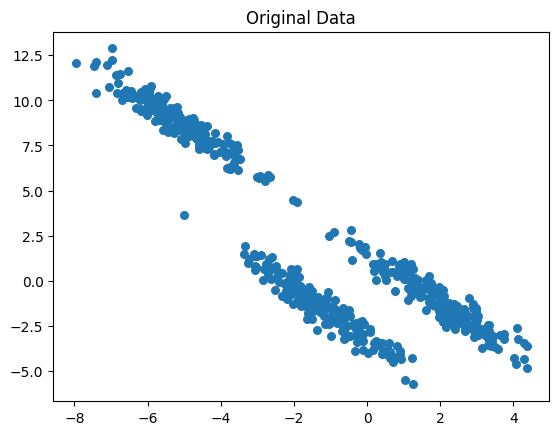

In [5]:
plt.scatter(X[:,0], X[:,1], s=30)
plt.title("Original Data")
plt.show()

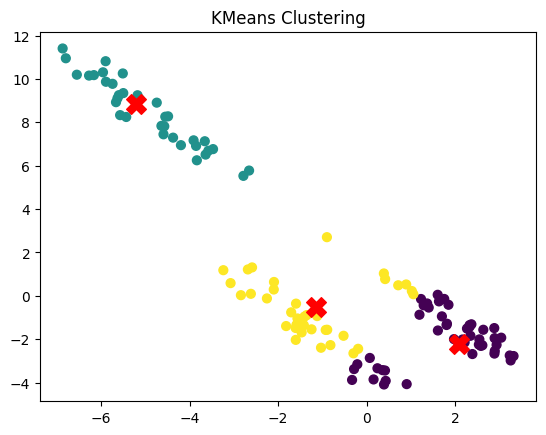

In [6]:
plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="red",
    marker="X",
    s=200
)

plt.title("KMeans Clustering")
plt.show()

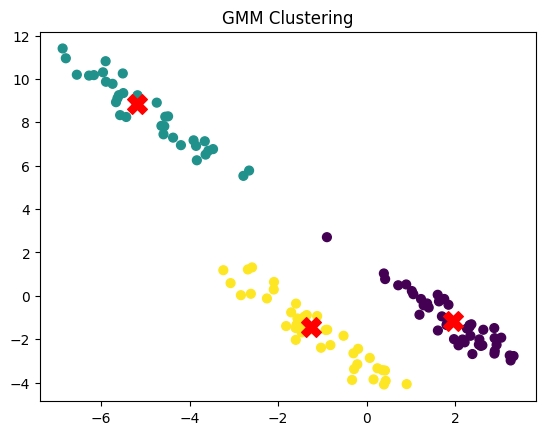

In [7]:
plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=gmm_labels,
    cmap="viridis",
    s=40
)

plt.scatter(
    gmm.means_[:,0],
    gmm.means_[:,1],
    c="red",
    marker="X",
    s=200
)

plt.title("GMM Clustering")
plt.show()

In [8]:
components = range(1,10)

aic_scores = []
bic_scores = []

for k in components:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_train)

    aic_scores.append(gmm.aic(X_train))
    bic_scores.append(gmm.bic(X_train))

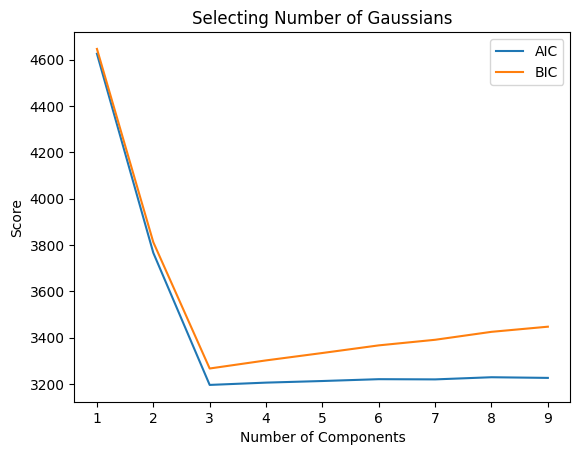

In [9]:
plt.plot(components, aic_scores, label="AIC")
plt.plot(components, bic_scores, label="BIC")

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("Selecting Number of Gaussians")
plt.legend()

plt.show()